In [5]:
import pandas as pd


In [4]:
df= pd.read_csv('C:/Users/Josue/4GA.Datascience/src/PASO5/VariablesTarget/testing/HappyLrscalePolintr/AllDataEu.csv')

In [107]:
import pandas as pd

def guardar_columnas_y_describe_en_archivo(df, nombre_archivo="columnas_y_describe.txt"):
    """
    Guarda los nombres de las columnas y el resultado de describe() de cada columna en un archivo de texto.

    Args:
        df (pd.DataFrame): El DataFrame original.
        nombre_archivo (str): El nombre del archivo de texto de salida.
    """

    with open(nombre_archivo, "w") as archivo:
        # Imprime los nombres de las columnas
        archivo.write("Nombres de las columnas:\n")
        for columna in df.columns:
            archivo.write(f"- {columna}\n")

        archivo.write("\n")  # Línea en blanco para separar

        # Imprime el resultado de describe() para cada columna
        archivo.write("Estadísticas descriptivas por columna:\n")
        for columna in df.columns:
            archivo.write(f"\nColumna: {columna}\n")
            archivo.write(str(df[columna].describe()) + "\n")


guardar_columnas_y_describe_en_archivo(df)

df = df.drop(['prob','stratum','name', 'essround', 'edition', 'proddate', 'idno', 'dweight',
       'pspwght', 'pweight', 'anweight','psu'],axis=1)

In [114]:
df['prob'].describe()

count    125069.000000
mean          0.000898
std           0.001991
min           0.000030
25%           0.000242
50%           0.000481
75%           0.000843
max           0.045450
Name: prob, dtype: float64

In [116]:
df['dweight'].describe()

count    433160.000000
mean          1.000015
std           0.391012
min           0.002272
25%           0.913189
50%           1.000000
75%           1.022936
max           5.261871
Name: dweight, dtype: float64

In [117]:
df['pspwght'].describe()

count    433160.000000
mean          1.002472
std           0.535582
min           0.000004
25%           0.703336
50%           0.925886
75%           1.172526
max           6.854967
Name: pspwght, dtype: float64

In [119]:
df['pweight'].describe()

count    433160.000000
mean          0.860421
std           0.909232
min           0.047563
25%           0.251379
50%           0.422835
75%           1.500921
max           5.447134
Name: pweight, dtype: float64

In [120]:
df['anweight'].describe()

count    356822.000000
mean          0.866521
std           1.141892
min           0.000001
25%           0.195016
50%           0.422338
75%           1.143225
max          21.997766
Name: anweight, dtype: float64

In [109]:
df['cntry'].describe()

count     177859
unique         9
top           IE
freq       24250
Name: cntry, dtype: object

In [110]:
df['cntry'].value_counts()

cntry
IE    24250
ES    21296
FI    21095
NL    20024
PL    19131
BE    19045
HU    18760
NO    17402
EE    16856
Name: count, dtype: int64

In [121]:
df['psu'].value_counts()

psu
5997.0     387
6097.0     184
5961.0     178
6054.0     114
5774.0      97
          ... 
14030.0      1
13138.0      1
14025.0      1
14029.0      1
13144.0      1
Name: count, Length: 27238, dtype: int64

In [9]:
import pandas as pd
import numpy as np

def marcar_atipicos_ordinales_nan_contador(df):
    """
    Marca los valores atípicos en columnas ordinales con NaN y cuenta los atípicos en 'contadornegativo'.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame modificado con la columna 'contadornegativo'.
    """

    df_modificado = df.copy()
    columnas_numericas = df_modificado.select_dtypes(include=np.number).columns
    df_modificado['contadornegativo'] = 0  # Inicializa la columna 'contadornegativo'

    for columna in columnas_numericas:
        max_valor = df_modificado[columna].max()

        if max_valor == 9:
            # Encuentra los índices de los valores atípicos
            indices_atipicos = df_modificado.loc[df_modificado[columna].isin([6, 7, 8, 9])].index

            # Marca los atípicos con NaN
            df_modificado.loc[indices_atipicos, columna] = np.nan

            # Suma +1 a 'contadornegativo' para las filas con atípicos
            df_modificado.loc[indices_atipicos, 'contadornegativo'] += 1

        elif max_valor == 5:
            # Encuentra los índices de los valores atípicos
            indices_atipicos = df_modificado.loc[df_modificado[columna].isin([0, 5])].index

            # Marca los atípicos con NaN
            df_modificado.loc[indices_atipicos, columna] = np.nan

            # Suma +1 a 'contadornegativo' para las filas con atípicos
            df_modificado.loc[indices_atipicos, 'contadornegativo'] += 1

    return df_modificado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df
df_modificado = marcar_atipicos_ordinales_nan_contador(df)

# Imprime la forma del DataFrame original y del DataFrame modificado
print(f"Forma del DataFrame original: {df.shape}")
print(f"Forma del DataFrame modificado: {df_modificado.shape}")

# Imprime la cantidad de valores NaN por columna en el DataFrame modificado
print(df_modificado.isnull().sum())

# Imprime la columna 'contadornegativo'
print(df_modificado['contadornegativo'].head(10)) #imprime los primeros 10 valores

Forma del DataFrame original: (433160, 177)
Forma del DataFrame modificado: (433160, 178)
name                     0
essround                 0
edition                  0
proddate                 0
idno                     0
                     ...  
ipsuces              82277
ipsucesa            400535
ipudrst              69327
ipudrsta            400535
contadornegativo         0
Length: 178, dtype: int64
0    3
1    5
2    3
3    2
4    7
5    2
6    8
7    1
8    2
9    1
Name: contadornegativo, dtype: int64


In [4]:
import pandas as pd

def obtener_lista_columnas(df):
  """Obtiene la lista de nombres de columnas de un DataFrame en formato de lista de Python."""
  lista_columnas = df.columns.tolist()
  return lista_columnas

# Supongamos que tu DataFrame se llama 'df'
lista_columnas = obtener_lista_columnas(df)

# Imprimir la lista de columnas en el formato deseado
print(lista_columnas)

# Ejemplo de como usar la lista de columnas.
print(f'lista de columnas: {lista_columnas}')

['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight', 'pspwght', 'pweight', 'anweight', 'prob', 'stratum', 'psu', 'netuse', 'netusoft', 'netustm', 'nwspol', 'nwsppol', 'nwsptot', 'pplfair', 'pplhlp', 'ppltrst', 'rdpol', 'rdtot', 'tvpol', 'tvtot', 'actrolg', 'actrolga', 'badge', 'bctprd', 'bghtprd', 'clsprty', 'contplt', 'cptppol', 'cptppola', 'dclagr', 'dclaid', 'dclcrm', 'dcldef', 'dclenv', 'dclintr', 'dclmig', 'dclwlfr', 'dmcntov', 'dntmny', 'ecohenv', 'etapapl', 'euftf', 'freehms', 'gincdif', 'ginveco', 'hmsacld', 'hmsfmlsh', 'ilglpst', 'implvdm', 'lawobey', 'lrscale', 'mmbprty', 'needtru', 'pbldmn', 'pbldmna', 'pltcare', 'pltinvt', 'polactiv', 'polcmpl', 'poldcs', 'polintr', 'prtdgcl', 'prtyban', 'psppipl', 'psppipla', 'psppsgv', 'psppsgva', 'pstplonl', 'ptcpplt', 'scnsenv', 'sgnptit', 'stfdem', 'stfeco', 'stfedu', 'stfgov', 'stfhlth', 'stflife', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'vote', 'wrkorg', 'wrkprty', 'ims

name                    0
essround                0
edition                 0
proddate                0
idno                    0
                    ...  
ipsuces                 0
ipsucesa                0
ipudrst                 0
ipudrsta                0
media_ponderada    433160
Length: 178, dtype: int64


In [ ]:
['netuse', 'netusoft', 'netustm', 'nwspol', 'nwsppol', 'nwsptot', 'pplfair', 'pplhlp', 'ppltrst', 'rdpol', 'rdtot', 'tvpol', 'tvtot', 'actrolg', 'actrolga', 'badge', 'bctprd', 'bghtprd', 'clsprty', 'contplt', 'cptppol', 'cptppola', 'dclagr', 'dclaid', 'dclcrm', 'dcldef', 'dclenv', 'dclintr', 'dclmig', 'dclwlfr', 'dmcntov', 'dntmny', 'ecohenv', 'etapapl', 'euftf', 'freehms', 'gincdif', 'ginveco', 'hmsacld', 'hmsfmlsh', 'ilglpst', 'implvdm', 'lawobey', 'lrscale', 'mmbprty', 'needtru', 'pbldmn', 'pbldmna', 'pltcare', 'pltinvt', 'polactiv', 'polcmpl', 'poldcs', 'polintr', 'prtdgcl', 'prtyban', 'psppipl', 'psppipla', 'psppsgv', 'psppsgva', 'pstplonl', 'ptcpplt', 'scnsenv', 'sgnptit', 'stfdem', 'stfeco', 'stfedu', 'stfgov', 'stfhlth', 'stflife', 'trstep', 'trstlgl', 'trstplc', 'trstplt', 'trstprl', 'trstprt', 'trstun', 'trstsci', 'vote', 'wrkorg', 'wrkprty', 'imsmetn', 'imdfetn', 'impcntr', 'imbgeco', 'imueclt', 'imwbcnt', 'volunfp', 'lrnobed', 'loylead', 'donprty', 'aesfdrk', 'atchctr', 'atcherp', 'brghmef', 'brghmwr', 'crmvct', 'crvctef', 'crvctwr', 'happy', 'health', 'inmdisc', 'inprdsc', 'rlgblg', 'rlgdgr', 'sclmeet', 'trrprsn', 'trrtort', 'ccnthum', 'wrclmch', 'vteurmmb', 'vteubcmb', 'ablrtr', 'atncrse', 'brwmny', 'dvrcdev', 'dvrcdeva', 'eduyrs', 'emplrel', 'emprelp', 'hincsrc', 'hincsrca', 'impdiff', 'impdiffa', 'impenv', 'impenva', 'impfree', 'impfreea', 'impfun', 'impfuna', 'imprich', 'impricha', 'impsafe', 'impsafea', 'imptrad', 'imptrada', 'ipadvnt', 'ipadvnta', 'ipbhprp', 'ipbhprpa', 'ipcrtiv', 'ipcrtiva', 'ipeqopt', 'ipeqopta', 'ipfrule', 'ipfrulea', 'ipgdtim', 'ipgdtima', 'iphlppl', 'iphlppla', 'iplylfr', 'iplylfra', 'ipmodst', 'ipmodsta', 'iprspot', 'iprspota', 'ipshabt', 'ipshabta', 'ipstrgv', 'ipstrgva', 'ipsuces', 'ipsucesa', 'ipudrst', 'ipudrsta']


In [10]:
import pandas as pd
import numpy as np

def marcar_atipicos_ordinales_nan_contador_10_acumulativo_df2(df2):
    """
    Marca los valores atípicos 66, 77, 88, 99 en columnas ordinales con NaN y acumula los atípicos en 'contadornegativo' en df2.

    Args:
        df2 (pd.DataFrame): El DataFrame df2 (resultado de procesar escalas 0-5).

    Returns:
        pd.DataFrame: El DataFrame modificado con la columna 'contadornegativo'.
    """

    df_modificado2 = df2.copy()
    columnas_numericas = df_modificado2.select_dtypes(include=np.number).columns

    # Asegurarse de que 'contadornegativo' existe, si no, inicializarla.
    if 'contadornegativo' not in df_modificado2.columns:
        df_modificado2['contadornegativo'] = 0

    for columna in columnas_numericas:
        max_valor = df_modificado2[columna].max()

        if max_valor == 99:
            # Encuentra los índices de los valores atípicos
            indices_atipicos = df_modificado2.loc[df_modificado2[columna].isin([66, 77, 88, 99])].index

            # Marca los atípicos con NaN
            df_modificado2.loc[indices_atipicos, columna] = np.nan

            # Suma +1 a 'contadornegativo' para las filas con atípicos
            df_modificado2.loc[indices_atipicos, 'contadornegativo'] += 1

        elif max_valor == 10:
            # Encuentra los índices de los valores atípicos
            indices_atipicos = df_modificado2.loc[df_modificado2[columna].isin([0, 10])].index

            # Marca los atípicos con NaN
            df_modificado2.loc[indices_atipicos, columna] = np.nan

            # Suma +1 a 'contadornegativo' para las filas con atípicos
            df_modificado2.loc[indices_atipicos, 'contadornegativo'] += 1

    return df_modificado2

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df_modificado2
df_modificado2 = marcar_atipicos_ordinales_nan_contador_10_acumulativo_df2(df_modificado)

# Imprime la forma del DataFrame original y del DataFrame modificado
print(f"Forma del DataFrame original: {df.shape}")
print(f"Forma del DataFrame modificado: {df_modificado2.shape}")

# Imprime la cantidad de valores NaN por columna en el DataFrame modificado
print(df_modificado2.isnull().sum())

# Imprime la columna 'contadornegativo'
print(df_modificado2['contadornegativo'].head(10))

Forma del DataFrame original: (433160, 177)
Forma del DataFrame modificado: (433160, 178)
name                     0
essround                 0
edition                  0
proddate                 0
idno                     0
                     ...  
ipsuces              82277
ipsucesa            401082
ipudrst              69327
ipudrsta            401068
contadornegativo         0
Length: 178, dtype: int64
0     4
1     5
2     6
3     2
4    12
5     4
6    11
7     1
8     2
9     7
Name: contadornegativo, dtype: int64


In [11]:
import pandas as pd
import numpy as np

def marcar_atipicos_netustm(df):
    """
    Marca los valores atípicos en la columna 'netustm' con NaN y actualiza 'contadornegativo'.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame modificado con la columna 'contadornegativo'.
    """

    df_modificado = df.copy()

    # Asegurarse de que 'contadornegativo' existe, si no, inicializarla.
    if 'contadornegativo' not in df_modificado.columns:
        df_modificado['contadornegativo'] = 0

    # Encuentra los índices de los valores atípicos
    indices_atipicos = df_modificado.loc[df_modificado['netustm'] > 1600].index

    # Marca los atípicos con NaN
    df_modificado.loc[indices_atipicos, 'netustm'] = np.nan

    # Suma +1 a 'contadornegativo' para las filas con atípicos
    df_modificado.loc[indices_atipicos, 'contadornegativo'] += 1

    return df_modificado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df_modificado2
df_modificado2 = marcar_atipicos_netustm(df_modificado2)

# Imprime la forma del DataFrame original y del DataFrame modificado
print(f"Forma del DataFrame original: {df.shape}")
print(f"Forma del DataFrame modificado: {df_modificado2.shape}")

# Imprime la cantidad de valores NaN en la columna 'netustm'
print(df_modificado2['netustm'].isnull().sum())

# Imprime la columna 'contadornegativo'
print(df_modificado2['contadornegativo'].head(10))

Forma del DataFrame original: (433160, 177)
Forma del DataFrame modificado: (433160, 178)
314909
0     4
1     5
2     6
3     2
4    12
5     4
6    11
7     1
8     2
9     7
Name: contadornegativo, dtype: int64


In [12]:
import pandas as pd
import numpy as np

def marcar_atipicos_nwspol(df):
    """
    Marca los valores atípicos en la columna 'nwspol' con NaN y actualiza 'contadornegativo'.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame modificado con la columna 'contadornegativo'.
    """

    df_modificado = df.copy()

    # Asegurarse de que 'contadornegativo' existe, si no, inicializarla.
    if 'contadornegativo' not in df_modificado.columns:
        df_modificado['contadornegativo'] = 0

    # Asumiendo que los valores atípicos son mayores a 1600 (ajusta según la escala real)
    indices_atipicos = df_modificado.loc[df_modificado['nwspol'] > 1600].index

    # Marca los atípicos con NaN
    df_modificado.loc[indices_atipicos, 'nwspol'] = np.nan

    # Suma +1 a 'contadornegativo' para las filas con atípicos
    df_modificado.loc[indices_atipicos, 'contadornegativo'] += 1

    return df_modificado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df_modificado2
df_modificado2 = marcar_atipicos_nwspol(df_modificado2)

# Imprime la forma del DataFrame original y del DataFrame modificado
print(f"Forma del DataFrame original: {df.shape}")
print(f"Forma del DataFrame modificado: {df_modificado2.shape}")

# Imprime la cantidad de valores NaN en la columna 'nwspol'
print(df_modificado2['nwspol'].isnull().sum())

# Imprime la columna 'contadornegativo'
print(df_modificado2['contadornegativo'].head(10))

Forma del DataFrame original: (433160, 177)
Forma del DataFrame modificado: (433160, 178)
274036
0     4
1     5
2     6
3     2
4    12
5     4
6    11
7     1
8     2
9     7
Name: contadornegativo, dtype: int64


In [14]:
import pandas as pd
import numpy as np

def discretizar_nwspol_ternario(df):
    """
    Discretiza la columna 'nwspol' en categorías ternarias.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame modificado con la columna 'nwspol_ternario'.
    """

    df_modificado = df.copy()

    # Discretización vectorizada
    df_modificado['nwspol_ternario'] = pd.cut(
        df_modificado['nwspol'],
        bins=[-float('inf'), 60, 180, float('inf')],
        labels=[0, 1, 2],
        right=True
    )

    return df_modificado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df_modificado2
df_modificado2 = discretizar_nwspol_ternario(df_modificado2)

# Imprime la forma del DataFrame original y del DataFrame modificado
print(f"Forma del DataFrame original: {df.shape}")
print(f"Forma del DataFrame modificado: {df_modificado2.shape}")

# Imprime la columna 'nwspol_ternario'
print(df_modificado2['nwspol_ternario'].value_counts())

Forma del DataFrame original: (433160, 177)
Forma del DataFrame modificado: (433160, 179)
nwspol_ternario
0    104328
1     43559
2     11237
Name: count, dtype: int64


In [15]:
import pandas as pd
import numpy as np

def discretizar_netustm_ternario(df):
    """
    Discretiza la columna 'netustm' en categorías ternarias.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame modificado con la columna 'netustm_ternario'.
    """

    df_modificado = df.copy()

    # Discretización vectorizada
    df_modificado['netustm_ternario'] = pd.cut(
        df_modificado['netustm'],
        bins=[-float('inf'), 60, 220, float('inf')],
        labels=[0, 1, 2],
        right=True
    )

    return df_modificado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df_modificado2
df_modificado2 = discretizar_netustm_ternario(df_modificado2)

# Imprime la forma del DataFrame original y del DataFrame modificado
print(f"Forma del DataFrame original: {df.shape}")
print(f"Forma del DataFrame modificado: {df_modificado2.shape}")

# Imprime la columna 'netustm_ternario'
print(df_modificado2['netustm_ternario'].value_counts())

Forma del DataFrame original: (433160, 177)
Forma del DataFrame modificado: (433160, 180)
netustm_ternario
1    48151
2    44146
0    25954
Name: count, dtype: int64


In [16]:
df_modificado2.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/testing/HappyLrscalePolintr/testclean.csv',index=False)

In [2]:
import pandas as pd
import numpy as np

def categorizar_escalas_ordinales_10(df):
    """
    Convierte automáticamente las columnas ordinales con valor máximo 10 en variables categóricas.
    Incluye una categoría 'Undefined' para los valores -1.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame con las columnas modificadas.
    """

    # Obtiene las columnas numéricas
    columnas_numericas = df.select_dtypes(include=np.number).columns

    # Crea una copia del DataFrame para evitar modificar el original
    df_copia = df.copy()

    # Itera sobre las columnas numéricas
    for columna in columnas_numericas:
        # Verifica el tipo de datos de la columna
        if df_copia[columna].dtype == 'object' or df_copia[columna].dtype == 'string':
            continue  # Omite la columna si es object o string
        elif df_copia[columna].dtype == 'float':
            # Reemplaza NaN e infinitos o mayores a 2000 con -1
            df_copia[columna] = df_copia[columna].fillna(-1).apply(lambda x: -1 if pd.isna(x) or x > 2000 else x).astype('int')

        max_valor = df_copia[columna].max()

        # Verifica si el valor máximo es 10
        if max_valor == 10:
            # Asigna categorías basadas en los rangos
            df_copia.loc[df_copia[columna] == -1, columna] = 0  # Categoría 0: Undefined
            df_copia.loc[df_copia[columna] < 5, columna] = 1  # Categoría 1: Bajo
            df_copia.loc[df_copia[columna] == 5, columna] = 2  # Categoría 2: Medio
            df_copia.loc[df_copia[columna] > 5, columna] = 3  # Categoría 3: Alto

            # Convierte la columna a tipo entero (opcional)
            df_copia[columna] = df_copia[columna].astype('Int64')

    return df_copia

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df3
df3_copia = categorizar_escalas_ordinales_10(df3)

# Imprime la distribución de las columnas modificadas
columnas_modificadas = [columna for columna in df3_copia.columns if df3[columna].max() == 10 ]
for columna in columnas_modificadas:
    print(f"Distribución de {columna}:")
    print(df3_copia[columna].value_counts().sort_index())

Distribución de pplfair:
pplfair
1     41038
2     33623
3    103198
Name: count, dtype: Int64
Distribución de pplhlp:
pplhlp
1    63035
2    35998
3    78826
Name: count, dtype: Int64
Distribución de ppltrst:
ppltrst
1    53740
2    33942
3    90177
Name: count, dtype: Int64
Distribución de actrolg:
actrolg
1    171563
2      1919
3      4377
Name: count, dtype: Int64
Distribución de cptppol:
cptppol
1    171084
2      2012
3      4763
Name: count, dtype: Int64
Distribución de dmcntov:
dmcntov
1    163206
2      2593
3     12060
Name: count, dtype: Int64
Distribución de etapapl:
etapapl
1    172420
2      2030
3      3409
Name: count, dtype: Int64
Distribución de euftf:
euftf
1    86874
2    32388
3    58597
Name: count, dtype: Int64
Distribución de implvdm:
implvdm
1    145882
2      1647
3     30330
Name: count, dtype: Int64
Distribución de lrscale:
lrscale
1    65605
2    52255
3    59999
Name: count, dtype: Int64
Distribución de psppipl:
psppipl
1    172351
2      2028
3      3480

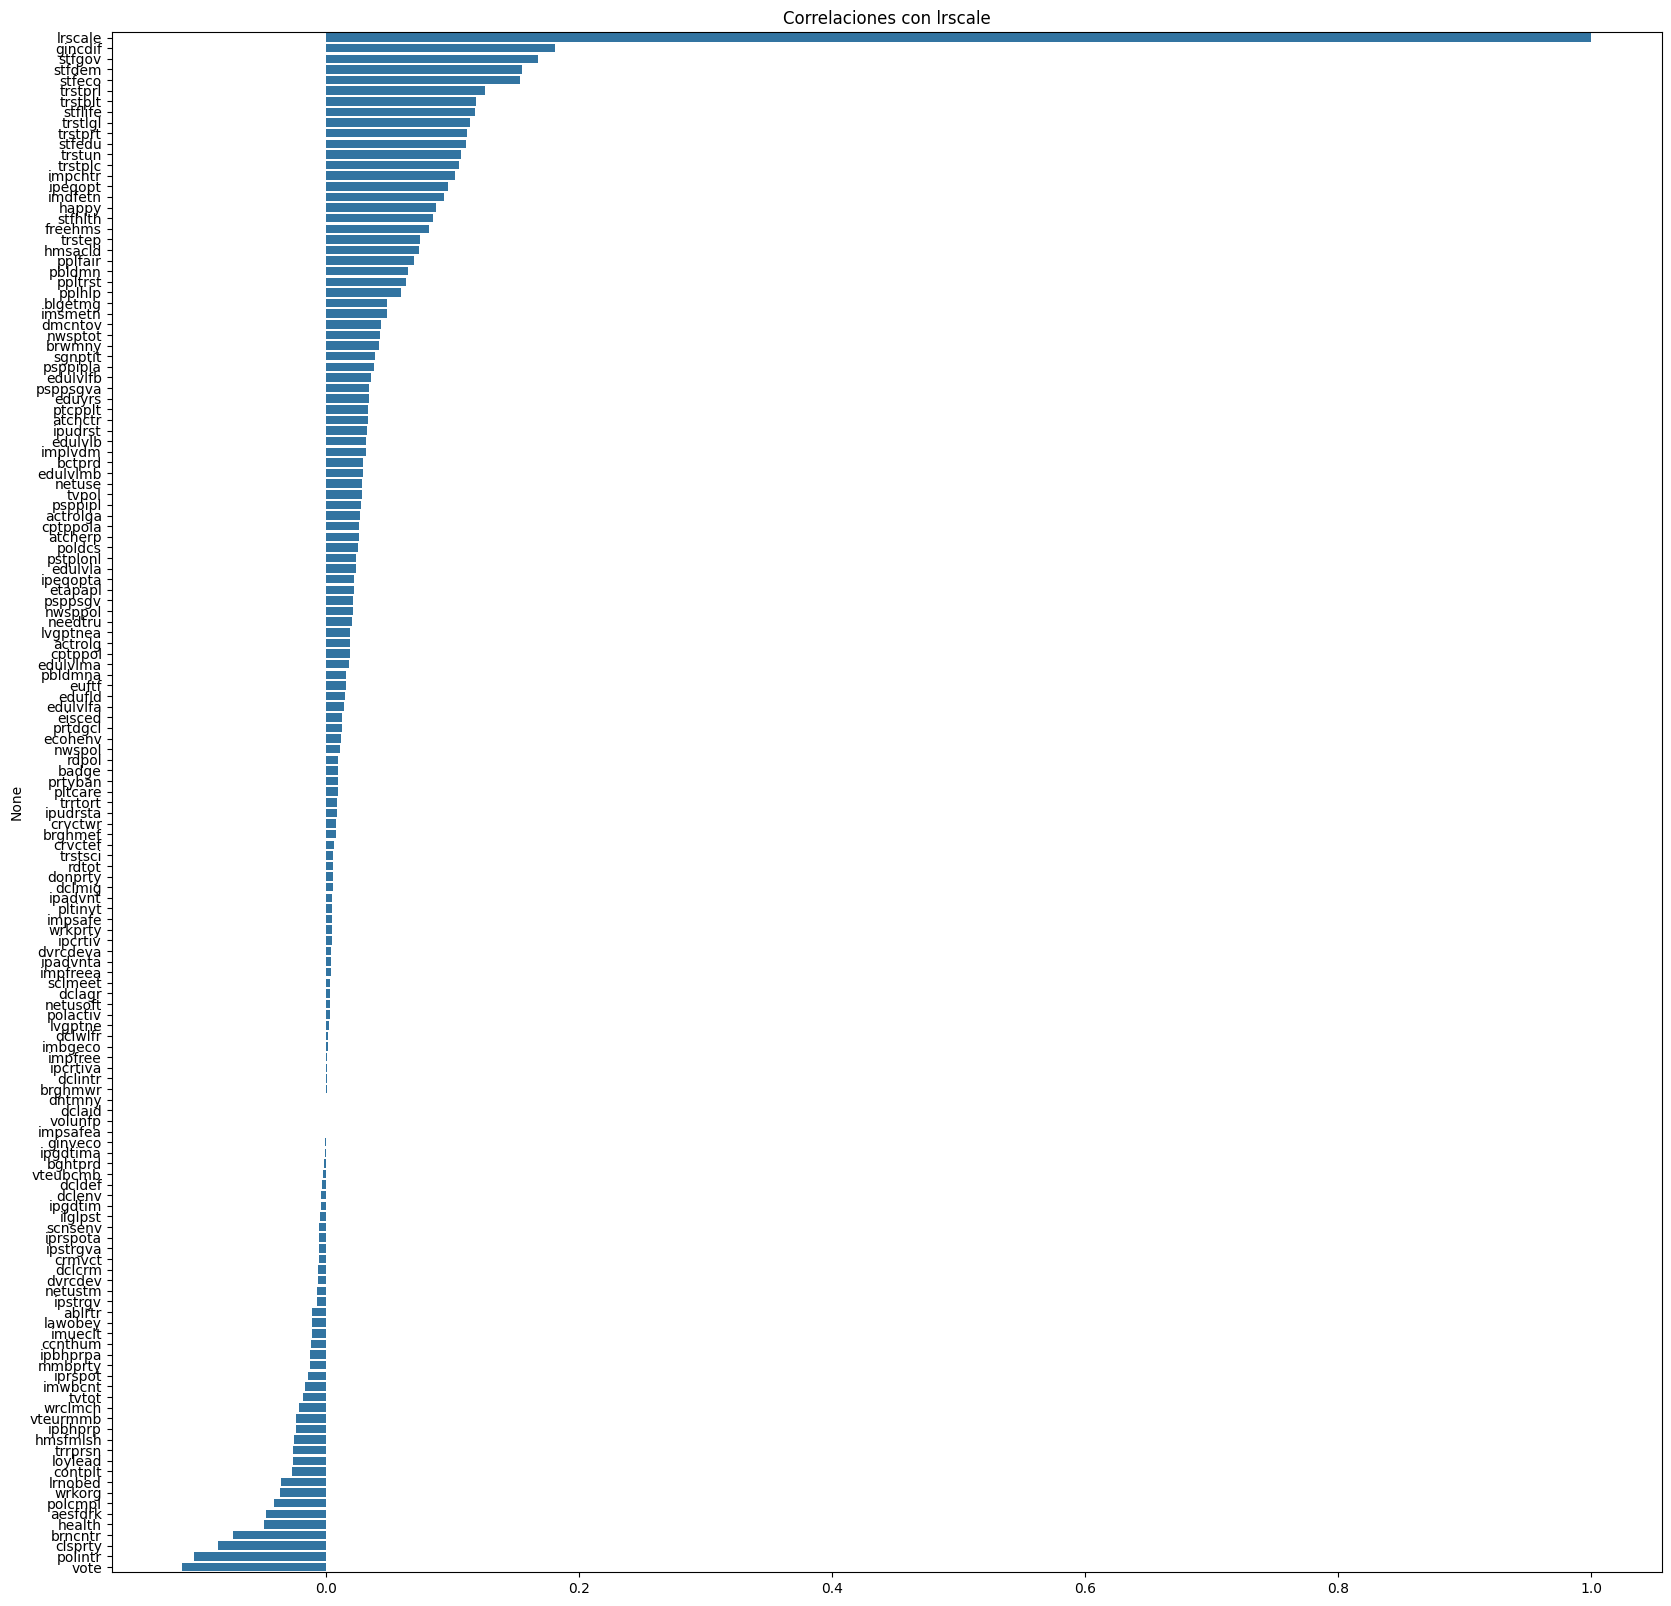

lrscale    1.000000
gincdif    0.180922
stfgov     0.168197
stfdem     0.155346
stfeco     0.153915
             ...   
health    -0.048453
brncntr   -0.073548
clsprty   -0.085081
polintr   -0.103640
vote      -0.113384
Name: lrscale, Length: 145, dtype: float64


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def encontrar_mejores_correlaciones(df, target_col):
    """
    Encuentra las columnas con las mejores correlaciones con la variable objetivo.

    Args:
        df (pd.DataFrame): El DataFrame que contiene los datos.
        target_col (str): El nombre de la columna objetivo.

    Returns:
        pd.Series: Una serie ordenada de las correlaciones con la variable objetivo.
    """

    # Calcula la matriz de correlación
    correlaciones = df.corr()[target_col].sort_values(ascending=False)

    # Visualiza las correlaciones (opcional)
    plt.figure(figsize=(20, 20))
    sns.barplot(x=correlaciones.values, y=correlaciones.index)
    plt.title(f'Correlaciones con {target_col}')
    plt.show()

    return correlaciones

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df
# y tu columna objetivo se llama 'lrscale'
correlaciones_lrscale = encontrar_mejores_correlaciones(df3_copia_redistribuido, 'lrscale')

# Imprime las correlaciones ordenadas
print(correlaciones_lrscale)

In [5]:
df3_copia.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/testing/HappyLrscalePolintr/testcat.csv', index=False)

In [12]:
import pandas as pd
df3_copia = pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/testing/HappyLrscalePolintr/testcat.csv')

In [6]:
del df3, columnas_modificadas, correlaciones_lrscale

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
from sklearn.utils import resample

def guardar_split_estratificado_reducido(df, target_col, test_size=0.20, random_state=42, sample_size=18000):
    """
    Guarda un split estratificado y reducido del DataFrame.

    Args:
        df (pd.DataFrame): El DataFrame original.
        target_col (str): El nombre de la columna objetivo.
        test_size (float): El tamaño del conjunto de prueba.
        random_state (int): La semilla aleatoria para la reproducibilidad.
        sample_size (int): El tamaño deseado de la muestra reducida.
    """

    # Separamos las target
    X = df.drop([target_col], axis=1)
    y = df[target_col]

    # Reducimos el tamaño de la muestra
    if len(df) > sample_size:
        df_reducido = resample(df, n_samples=sample_size, random_state=random_state, stratify=df[target_col])
        X = df_reducido.drop([target_col], axis=1)
        y = df_reducido[target_col]

    # Realizamos el split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Guardamos el split
    joblib.dump(
        (X_train, X_test, y_train, y_test),
        "C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/lrscale.pkl",
    )

    print("Splits guardados correctamente.")

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df y tu columna objetivo es 'lrscale'
guardar_split_estratificado_reducido(df3_copia_redistribuido, 'lrscale')

Splits guardados correctamente.


In [48]:
df3_copia_redistribuido['vote'].value_counts()

vote
1    130687
2     32512
3     14660
Name: count, dtype: int64

In [49]:
df3_copia_redistribuido['nwspol'].describe()

count    177859.000000
mean         59.262854
std          82.601800
min           0.000000
25%          25.000000
50%          49.000000
75%          71.000000
max        1440.000000
Name: nwspol, dtype: float64

In [ ]:
import pandas as pd
import numpy as np

def reemplazar_menos_uno_con_nan_en_todas(df):


    df_copia = df.copy()

   
    for columna in df_copia.columns:
       
        df_copia[columna] = np.where(df_copia[columna] == -1, np.nan, df_copia[columna])

    return df_copia


df3_copia_nan = reemplazar_menos_uno_con_nan_en_todas(df3_copia)

print(df3_copia_nan)

        netuse  netusoft  netustm  nwspol  nwsppol  nwsptot  pplfair  pplhlp  \
0          0.0       NaN      NaN     NaN      NaN      0.0      3.0     1.0   
1          2.0       NaN      NaN     NaN      NaN      0.0      3.0     2.0   
2          1.0       NaN      NaN     NaN      NaN      0.0      3.0     3.0   
3          7.0       NaN      NaN     NaN      2.0      2.0      3.0     2.0   
4          1.0       NaN      NaN     NaN      1.0      2.0      3.0     2.0   
...        ...       ...      ...     ...      ...      ...      ...     ...   
177854     NaN       5.0    240.0    60.0      NaN      NaN      1.0     1.0   
177855     NaN       3.0      NaN    30.0      NaN      NaN      3.0     3.0   
177856     NaN       2.0      NaN   120.0      NaN      NaN      2.0     3.0   
177857     NaN       5.0     60.0    90.0      NaN      NaN      1.0     2.0   
177858     NaN       5.0    120.0    90.0      NaN      NaN      2.0     3.0   

        ppltrst  rdpol  ...  ipeqopt  i

In [25]:
import pandas as pd
import numpy as np

def distribuir_nan_por_escala(df):
    """
    Distribuye los valores NaN por escala (0-4, 0-5, 0-6, 0-10, 1-3) usando puntos de corte diferentes.

    Args:
        df (pd.DataFrame): El DataFrame original.

    Returns:
        pd.DataFrame: El DataFrame con los valores NaN distribuidos.
    """

    df_copia = df.copy()

    for columna in df_copia.columns:
        valores_nan = df_copia[columna].isnull()
        indices_nan = df_copia.index[valores_nan].tolist()

        if not indices_nan:
            continue  # No hay valores NaN en esta columna

        valores_originales = df[columna].dropna()  # Excluye NaN
        max_valor = valores_originales.max()

        # Calcula los puntos de corte según la escala
        if max_valor == 4:
            corte1 = valores_originales.quantile(0.25)
            corte2 = valores_originales.quantile(0.50)
            corte3 = valores_originales.quantile(0.75)
        elif max_valor == 5:
            corte1 = valores_originales.quantile(0.20)
            corte2 = valores_originales.quantile(0.40)
            corte3 = valores_originales.quantile(0.60)
        elif max_valor == 6:
            corte1 = valores_originales.quantile(1/6)
            corte2 = valores_originales.quantile(2/6)
            corte3 = valores_originales.quantile(3/6)
        elif max_valor == 10:
            corte1 = valores_originales.quantile(0.10)
            corte2 = valores_originales.quantile(0.20)
            corte3 = valores_originales.quantile(0.30)
        elif max_valor == 3:  # Escala ternaria (1-3)
            corte1 = valores_originales.quantile(1/3)
            corte2 = valores_originales.quantile(2/3)
            corte3 = valores_originales.max()
        elif max_valor == 1: # Escala binaria (0-1)
            corte1 = valores_originales.quantile(0.50)
            corte2 = valores_originales.max()
            corte3 = valores_originales.max()
        else:
            # Escala desconocida, usa cuartiles estándar
            corte1 = valores_originales.quantile(0.25)
            corte2 = valores_originales.quantile(0.50)
            corte3 = valores_originales.quantile(0.75)

        # Genera números aleatorios para cada NaN
        valores_aleatorios = np.random.rand(len(indices_nan))

        # Crea máscaras booleanas para cada tercio
        mascara_tercio1 = valores_aleatorios < 1/3
        mascara_tercio2 = (valores_aleatorios >= 1/3) & (valores_aleatorios < 2/3)
        mascara_tercio3 = valores_aleatorios >= 2/3

        # Convierte la lista de índices a un array de NumPy
        indices_nan_array = np.array(indices_nan)

        # Asigna valores aleatorios dentro de los rangos de tercios
        try:
            df_copia.loc[indices_nan_array[np.where(mascara_tercio1)[0]], columna] = np.random.uniform(valores_originales.min(), corte1, size=mascara_tercio1.sum())
            df_copia.loc[indices_nan_array[np.where(mascara_tercio2)[0]], columna] = np.random.uniform(corte1, corte2, size=mascara_tercio2.sum())
            df_copia.loc[indices_nan_array[np.where(mascara_tercio3)[0]], columna] = np.random.uniform(corte2, corte3, size=mascara_tercio3.sum())
        except OverflowError:
            print(f"OverflowError en la columna {columna}. Ajustando rangos...")
            min_val = valores_originales.min()
            df_copia.loc[indices_nan_array[np.where(mascara_tercio1)[0]], columna] = np.random.uniform(min_val, min_val + (corte1 - min_val) / 10, size=mascara_tercio1.sum())
            df_copia.loc[indices_nan_array[np.where(mascara_tercio2)[0]], columna] = np.random.uniform(corte1, corte1 + (corte2 - corte1) / 10, size=mascara_tercio2.sum())
            df_copia.loc[indices_nan_array[np.where(mascara_tercio3)[0]], columna] = np.random.uniform(corte2, corte2 + (corte3 - corte2) / 10, size=mascara_tercio3.sum())
        # Convierte los valores a enteros (si es necesario)
        df_copia[columna] = df_copia[columna].round().astype(int)

    return df_copia

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df3_copia_nan
df3_copia_redistribuido = distribuir_nan_por_escala(df3_copia_nan)

# Imprime el DataFrame resultante
print(df3_copia_redistribuido)
print(df3_copia_redistribuido)

        netuse  netusoft  netustm  nwspol  nwsppol  nwsptot  pplfair  pplhlp  \
0            0         2       91      87        0        0      3.0     1.0   
1            2         3       68      75        1        0      3.0     2.0   
2            1         1      248      18        1        0      3.0     3.0   
3            7         5      247      47        2        2      3.0     2.0   
4            1         5      156      36        1        2      3.0     2.0   
...        ...       ...      ...     ...      ...      ...      ...     ...   
177854       0         5      240      60        1        0      1.0     1.0   
177855       0         3      228      30        2        1      3.0     3.0   
177856       0         2      213     120        2        1      2.0     3.0   
177857       2         5       60      90        2        2      1.0     2.0   
177858       0         5      120      90        0        1      2.0     3.0   

        ppltrst  rdpol  ...  ipeqopt  i

In [14]:
import pandas as pd
import numpy as np

def reemplazar_menos_uno_con_nan(df, columnas):
    """
    Reemplaza los valores -1 con NaN en las columnas especificadas.

    Args:
        df (pd.DataFrame): El DataFrame original.
        columnas (list): Lista de nombres de columnas a reemplazar.

    Returns:
        pd.DataFrame: El DataFrame con los valores -1 reemplazados por NaN.
    """

    df_copia = df.copy()

    for columna in columnas:
        df_copia.loc[df_copia[columna] == -1, columna] = np.nan

    return df_copia

def distribuir_nan_equitativamente(df, columnas):
    """
    Distribuye los valores NaN equitativamente en las columnas especificadas.

    Args:
        df (pd.DataFrame): El DataFrame original.
        columnas (list): Lista de nombres de columnas a distribuir.

    Returns:
        pd.DataFrame: El DataFrame con los valores NaN distribuidos.
    """

    df_copia = df.copy()

    for columna in columnas:
        valores_nan = df_copia[columna].isnull()
        indices_nan = df_copia.index[valores_nan].tolist()

        if not indices_nan:
            continue  # No hay valores NaN en esta columna

        valores_originales = df[columna].dropna()  # Excluye NaN
        q1 = valores_originales.quantile(0.25)
        q2 = valores_originales.quantile(0.50)
        q3 = valores_originales.quantile(0.75)

        for indice in indices_nan:
            valor_aleatorio = np.random.rand()
            if valor_aleatorio < 0.25:
                df_copia.loc[indice, columna] = np.random.uniform(valores_originales.min(), q1)
            elif valor_aleatorio < 0.50:
                df_copia.loc[indice, columna] = np.random.uniform(q1, q2)
            else:
                df_copia.loc[indice, columna] = np.random.uniform(q2, q3)

        # Convierte los valores a enteros (si es necesario)
        df_copia[columna] = df_copia[columna].astype(int)

    return df_copia

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df3_copia
columnas_numericas = df3_copia.select_dtypes(include=np.number).columns.tolist() #Seleccionar solo columnas numéricas.

# Reemplaza -1 con NaN
df3_copia_nan = reemplazar_menos_uno_con_nan(df3_copia, columnas_numericas)

# Distribuye NaN equitativamente
df3_copia_redistribuido = distribuir_nan_equitativamente(df3_copia_nan, columnas_numericas)

# Imprime la distribución de las columnas redistribuidas
for columna in columnas_numericas:
    print(f"Distribución de {columna} (después de la redistribución):")
    print(df3_copia_redistribuido[columna].value_counts().sort_index())

KeyboardInterrupt: 

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
from sklearn.utils import resample

def guardar_split_estratificado_reducido(df, target_col, test_size=0.20, random_state=42, sample_size=18000):
    """
    Guarda un split estratificado y reducido del DataFrame.

    Args:
        df (pd.DataFrame): El DataFrame original.
        target_col (str): El nombre de la columna objetivo.
        test_size (float): El tamaño del conjunto de prueba.
        random_state (int): La semilla aleatoria para la reproducibilidad.
        sample_size (int): El tamaño deseado de la muestra reducida.
    """

    # Separamos las target
    X = df.drop(['happy'], axis=1)
    y = df['happy']

    # Reducimos el tamaño de la muestra
    if len(df) > sample_size:
        df_reducido = resample(df, n_samples=sample_size, random_state=random_state, stratify=df[target_col])
        X = df_reducido.drop([target_col], axis=1)
        y = df_reducido[target_col]

    # Realizamos el split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Guardamos el split
    joblib.dump(
        (X_train, X_test, y_train, y_test),
        "C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/happy.pkl",
    )

    print("Splits guardados correctamente.")

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df y tu columna objetivo es 'lrscale'
guardar_split_estratificado_reducido(df3_copia_redistribuido, 'happy')

Splits guardados correctamente.


In [66]:
df =pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/testing/HappyLrscalePolintr/testcat.csv')

In [67]:
df['nwspol'].describe()

count    163199.000000
mean         59.848535
std          82.637635
min           0.000000
25%          25.000000
50%          49.000000
75%          72.000000
max        1440.000000
Name: nwspol, dtype: float64

In [91]:
import pandas as pd

def disvar(df):
    """
    Discretiza la variable nwspol en 3 bins (bajo, medio, alto) y convierte a entero.

    Args:
        df (pd.DataFrame): El DataFrame que contiene la variable nwspol.

    Returns:
        pd.DataFrame: El DataFrame con la variable nwspol discretizada (como entero).
    """

    df['nwspol_discreto'] = 2  # Inicializamos con 'alto' por defecto
    df.loc[df['nwspol'] < 25, 'nwspol_discreto'] = 0
    df.loc[(df['nwspol'] >= 25) & (df['nwspol'] <= 71), 'nwspol_discreto'] = 1

    # Convertir a entero explícitamente
    df['nwspol_discreto'] = df['nwspol_discreto'].astype(int)

    return df

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df
df = disvar(df)




C:\Users\Josue\AppData\Local\Temp\ipykernel_14308\4045450568.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['nwspol_discreto'] = 2  # Inicializamos con 'alto' por defecto
C:\Users\Josue\AppData\Local\Temp\ipykernel_14308\4045450568.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['nwspol_discreto'] = df['nwspol_discreto'].astype(int)


In [69]:
def discretizar_eduyrs(df):
    """
    Discretiza la variable eduyrs en 3 bins (bajo, medio, alto) usando operaciones vectorizadas y replace.

    Args:
        df (pd.DataFrame): El DataFrame que contiene la variable eduyrs.

    Returns:
        pd.DataFrame: El DataFrame con la variable eduyrs discretizada.
    """

    df['eduyrs_discreto'] = 2  # Inicializamos con 'alto' (2) por defecto
    df.loc[df['eduyrs'] < 10, 'eduyrs_discreto'] = 0  # 'bajo' (0)
    df.loc[(df['eduyrs'] >= 10) & (df['eduyrs'] <= 14), 'eduyrs_discreto'] = 1  # 'medio' (1)

    return df

df = discretizar_eduyrs(df)

In [71]:
def eliminar_menores(df, vote_col='vote'):
    """
    Elimina las filas donde la variable vote es igual a 3 (menores de edad).

    Args:
        df (pd.DataFrame): El DataFrame original.
        vote_col (str): Nombre de la columna vote.

    Returns:
        pd.DataFrame: El DataFrame sin las filas de menores de edad.
    """

    df_filtrado = df.loc[df[vote_col] != 3]

    return df_filtrado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df
df = eliminar_menores(df3)

NameError: name 'df3' is not defined

In [73]:
df['tvpol'].describe()

count    163199.000000
mean          1.790268
std           1.186702
min           0.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           7.000000
Name: tvpol, dtype: float64

In [ ]:
import pandas as pd

def discretizar_tvpol(df):


    df['tvpol_discreto'] = 2 # Inicializamos con 'alto' (2) por defecto
    df.loc[df['tvpol'] <= 1, 'tvpol_discreto'] = 0 # 'bajo' (0)
    df.loc[df['tvpol'] == 2, 'tvpol_discreto'] = 1 # 'medio' (1)

    return df


df3_copia_redistribuido= discretizar_tvpol(df3_copia_redistribuido)

C:\Users\Josue\AppData\Local\Temp\ipykernel_14308\3406509505.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tvpol_discreto'] = 2 # Inicializamos con 'alto' (2) por defecto


In [74]:
df['netustm'].describe()

count    163199.000000
mean        162.012163
std         126.092586
min           0.000000
25%          71.000000
50%         140.000000
75%         226.000000
max        1440.000000
Name: netustm, dtype: float64

In [75]:
import pandas as pd

def discretizar_netustm_v2(df):


    df['netustm_discreto'] = 2  # Inicializamos con 'alto' (2) por defecto
    df.loc[(df['netustm'] >= 0) & (df['netustm'] <= 80), 'netustm_discreto'] = 0  # 'bajo' (0)
    df.loc[(df['netustm'] >= 81) & (df['netustm'] <= 180), 'netustm_discreto'] = 1  # 'medio' (1)

    return df


df= discretizar_netustm_v2(df)

In [79]:
df['polcmpl_discreto'].describe()

count    163199.000000
mean          0.714588
std           0.685654
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: polcmpl_discreto, dtype: float64

In [ ]:


def discretizar_polcmpl(df):


    df['polcmpl_discreto'] = 2  # Inicializamos con 'alto' (2) por defecto
    df.loc[df['polcmpl'] <= 2, 'polcmpl_discreto'] = 0  # 'bajo' (0)
    df.loc[df['polcmpl'] == 3, 'polcmpl_discreto'] = 1  # 'medio' (1)

    return df


df = discretizar_polcmpl(df)

In [87]:


def tratar_nwspol(df, nwspol_col='nwspol'):
    """
    Elimina los outliers positivos de nwspol y discretiza la variable en 3 bins.

    Args:
        df (pd.DataFrame): El DataFrame que contiene la variable nwspol.
        nwspol_col (str): Nombre de la columna nwspol.

    Returns:
        pd.DataFrame: El DataFrame con la variable nwspol tratada y discretizada.
    """

    # 1. Eliminar Outliers Positivos
    tercer_cuartil = df[nwspol_col].quantile(0.75)
    df[nwspol_col] = df[nwspol_col].apply(lambda x: np.nan if x > tercer_cuartil else x)
    df = df.dropna(subset=[nwspol_col])

    # 2. Discretizar con Percentiles 33 y 66
    percentil_33 = df[nwspol_col].quantile(0.33)
    percentil_66 = df[nwspol_col].quantile(0.66)

    bins = [0, percentil_33, percentil_66, float('inf')]
    labels = [0, 1, 2]
    df['nwspol_discreto'] = pd.cut(df[nwspol_col], bins=bins, labels=labels, right=False)

    return df


df = tratar_nwspol(df)

C:\Users\Josue\AppData\Local\Temp\ipykernel_14308\2600190864.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['nwspol_discreto'] = pd.cut(df[nwspol_col], bins=bins, labels=labels, right=False)


In [64]:
import pandas as pd
import numpy as np

def nans(df, nwspol_col='nwspol'):
    """
    Reemplaza los valores atípicos de la variable nwspol con NaN y luego rellena los NaN con la media.

    Args:
        df (pd.DataFrame): El DataFrame que contiene la variable nwspol.
        nwspol_col (str): Nombre de la columna nwspol.

    Returns:
        pd.DataFrame: El DataFrame con los valores atípicos rellenados con la media.
    """

    tercer_cuartil = df[nwspol_col].quantile(0.75)  # Calcula el tercer cuartil
    df[nwspol_col] = df[nwspol_col].apply(lambda x: np.nan if x > tercer_cuartil else x)  # Reemplaza atípicos con NaN
    media_nwspol = df[nwspol_col].mean()  # Calcula la media de nwspol
    df[nwspol_col] = df[nwspol_col].fillna(media_nwspol)  # Rellena los NaN con la media

    return df


df = nans(df)

In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

def guardar_split_estratificado_reducido_smote(df, target_col, test_size=0.20, random_state=42, sample_size=18000, eduyrs_col='eduyrs_discreto'):
 

    # Separamos las target
    X = df.drop(['polintr', 'happy','lrscale'], axis=1)
    y = df['polintr']

    # Reducimos el tamaño de la muestra
    if len(df) > sample_size:
        df_reducido = resample(df, n_samples=sample_size, random_state=random_state, stratify=df[target_col])
        X = df_reducido.drop([target_col], axis=1)
        y = df_reducido[target_col]

    # Realizamos el split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Aplicamos SMOTE solo al conjunto de entrenamiento
    smote = SMOTE(random_state=random_state)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Guardamos el split
    joblib.dump(
        (X_train_smote, X_test, y_train_smote, y_test),
        "C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/polintr2.pkl",
    )

    print("Splits guardados correctamente con SMOTE aplicado.")

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame llamado df3_copia_redistribuido y tu columna objetivo es 'polintr'
guardar_split_estratificado_reducido_smote(df, 'polintr')

Splits guardados correctamente con SMOTE aplicado.


In [101]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
import joblib
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, KFold

def xgboost_con_hyperopt_seleccion_caracteristicas(X_train, y_train, X_test, y_test, ruta_guardado=None, max_evals=20, max_features=None):
    """
    Entrena un modelo XGBoost con Hyperopt y selección automática de características.

    Args:
        X_train (pd.DataFrame): Datos de entrenamiento para las características.
        y_train (pd.Series): Datos de entrenamiento para la variable objetivo.
        X_test (pd.DataFrame): Datos de prueba para las características.
        y_test (pd.Series): Datos de prueba para la variable objetivo.
        ruta_guardado (str, opcional): Ruta para guardar el modelo y las métricas.
        max_evals (int, opcional): Número máximo de evaluaciones de Hyperopt.
        max_features (int, opcional): Número máximo de características a utilizar. Si es None, se usan todas las características.

    Returns:
        xgb.XGBClassifier: El mejor modelo XGBoost entrenado.
    """

    # Ajustar las etiquetas para que comiencen en 0
    y_train_adjusted = y_train.copy()
    y_test_adjusted = y_test.copy()

    y_train_adjusted[y_train_adjusted != -1] = y_train_adjusted[y_train_adjusted != -1] - 1
    y_test_adjusted[y_test_adjusted != -1] = y_test_adjusted[y_test_adjusted != -1] - 1
    y_train_adjusted[y_train_adjusted == -1] = 0
    y_test_adjusted[y_test_adjusted == -1] = 0

    space = {
        'max_depth': hp.quniform('max_depth', 1, 16, 1),  # Paso 1
        'learning_rate': hp.loguniform('learning_rate', -5, 0),
        'n_estimators': hp.quniform('n_estimators', 10, 300, 10),  # Paso 10
        'subsample': hp.uniform('subsample', 0.5, 1),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
        'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),  # Paso 1
        'gamma': hp.uniform('gamma', 0, 1),
    }

    def objective(params):
        modelo = xgb.XGBClassifier(
            max_depth=int(params['max_depth']),  # Convertir a entero
            learning_rate=params['learning_rate'],
            n_estimators=int(params['n_estimators']),  # Convertir a entero
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=int(params['min_child_weight']),  # Convertir a entero
            gamma=params['gamma'],
            random_state=42,
            eval_metric='logloss'
        )
        modelo.fit(X_train, y_train_adjusted)
        y_pred = modelo.predict(X_test)
        score = accuracy_score(y_test_adjusted, y_pred)
        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials)

    mejor_modelo = xgb.XGBClassifier(
        max_depth=int(best['max_depth']),  # Convertir a entero
        learning_rate=best['learning_rate'],
        n_estimators=int(best['n_estimators']),  # Convertir a entero
        subsample=best['subsample'],
        colsample_bytree=best['colsample_bytree'],
        min_child_weight=int(best['min_child_weight']),  # Convertir a entero
        gamma=best['gamma'],
        random_state=42,
        eval_metric='logloss'
    )
    mejor_modelo.fit(X_train, y_train_adjusted, verbose=False)

    # Selección de características basada en la importancia
    if max_features is not None and max_features < X_train.shape[1]:
        feature_importance = mejor_modelo.feature_importances_
        indices_ordenados = np.argsort(feature_importance)[::-1]
        selected_features = X_train.columns[indices_ordenados[:max_features]]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]
        mejor_modelo.fit(X_train, y_train_adjusted, verbose=False)  # Reentrenar con las mejores features.

    y_pred = mejor_modelo.predict(X_test)
    y_pred_proba = mejor_modelo.predict_proba(X_test)
    auc = roc_auc_score(y_test_adjusted, y_pred_proba, multi_class='ovr')
    accuracy = accuracy_score(y_test_adjusted, y_pred)

    # Validación cruzada con KFold (aleatoriedad controlada)
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_scores = cross_val_score(mejor_modelo, X_train, y_train_adjusted, cv=kf, scoring='accuracy')

    print("\nMejor modelo encontrado (XGBoost Hyperopt con Selección de Características):")
    print(f"best_params: {best}")
    print(f"AUC: {auc}")
    print(f"Accuracy: {accuracy}")
    print(f"Cross-Validation Accuracy: {np.mean(cv_scores)}")

    if ruta_guardado:
        joblib.dump(mejor_modelo, f"{ruta_guardado}mejor_modelo_xgboost_seleccion_caracteristicas.pkl")
        with open(f"{ruta_guardado}metricas_xgboost_seleccion_caracteristicas.txt", "w") as f:
            f.write(f"best_params: {best}\n")
            f.write(f"AUC: {auc}\n")
            f.write(f"Accuracy: {accuracy}\n")
            f.write(f"Cross-Validation Accuracy: {np.mean(cv_scores)}\n")
            f.write(f"Predictoras utilizadas: {list(X_train.columns) if isinstance(X_train, pd.DataFrame) else list(range(X_train.shape[1]))}\n")
            f.write(f"Variable objetivo: {y_train.name if hasattr(y_train, 'name') else 'desconocido'}\n")

    return mejor_modelo

# Ejemplo de uso:
# Cargar los datos de entrenamiento y prueba
X_train, X_test, y1_train, y1_test = joblib.load("C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/polintr2.pkl")

# Entrenar el modelo con selección automática de características (máximo 8 características)
mejor_modelo_lr4d = xgboost_con_hyperopt_seleccion_caracteristicas(X_train, y1_train, X_test, y1_test, ruta_guardado="C:/Users/Josue/4GA.Datascience/4GA.DataScience/models/", max_features=12)

100%|██████████| 20/20 [01:12<00:00,  3.62s/trial, best loss: -0.5747222222222222]

Mejor modelo encontrado (XGBoost Hyperopt con Selección de Características):
best_params: {'colsample_bytree': np.float64(0.8595313787621852), 'gamma': np.float64(0.1594712767016735), 'learning_rate': np.float64(0.10012818941698592), 'max_depth': np.float64(10.0), 'min_child_weight': np.float64(8.0), 'n_estimators': np.float64(170.0), 'subsample': np.float64(0.5031938055234071)}
AUC: 0.7025759647975958
Accuracy: 0.4652777777777778
Cross-Validation Accuracy: 0.5749912293300621


In [102]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
import joblib
from sklearn.model_selection import cross_val_score, KFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer

def xgboost_con_bayesian_search_seleccion_caracteristicas(X_train, y_train, X_test, y_test, ruta_guardado=None, n_iter=50, max_features=12):
    """
    Entrena un modelo XGBoost con BayesianSearchCV y selección automática de características.

    Args:
        X_train (pd.DataFrame): Datos de entrenamiento para las características.
        y_train (pd.Series): Datos de entrenamiento para la variable objetivo.
        X_test (pd.DataFrame): Datos de prueba para las características.
        y_test (pd.Series): Datos de prueba para la variable objetivo.
        ruta_guardado (str, opcional): Ruta para guardar el modelo y las métricas.
        n_iter (int, opcional): Número de iteraciones de BayesianSearchCV.
        max_features (int, opcional): Número máximo de características a utilizar.

    Returns:
        xgb.XGBClassifier: El mejor modelo XGBoost entrenado.
    """

    # Ajustar las etiquetas para que comiencen en 0
    y_train_adjusted = y_train.copy()
    y_test_adjusted = y_test.copy()

    y_train_adjusted[y_train_adjusted != -1] = y_train_adjusted[y_train_adjusted != -1] - 1
    y_test_adjusted[y_test_adjusted != -1] = y_test_adjusted[y_test_adjusted != -1] - 1
    y_train_adjusted[y_train_adjusted == -1] = 0
    y_test_adjusted[y_test_adjusted == -1] = 0

    param_dist = {
        'max_depth': Integer(8, 12),  # Rango estrecho alrededor de 10
        'learning_rate': Real(0.08, 0.12),  # Rango estrecho alrededor de 0.1
        'n_estimators': Integer(150, 200),  # Rango estrecho alrededor de 170
        'subsample': Real(0.48, 0.52),  # Rango estrecho alrededor de 0.5
        'colsample_bytree': Real(0.8, 0.9),  # Rango estrecho alrededor de 0.85
        'min_child_weight': Integer(6, 10),  # Rango estrecho alrededor de 8
        'gamma': Real(0.1, 0.2),  # Rango estrecho alrededor de 0.15
    }

    modelo = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

    bayesian_search = BayesSearchCV(
        modelo,
        search_spaces=param_dist,
        n_iter=n_iter,
        cv=KFold(n_splits=6, shuffle=True, random_state=42),
        scoring='accuracy',
        random_state=42
    )

    bayesian_search.fit(X_train, y_train_adjusted)
    mejor_modelo = bayesian_search.best_estimator_

    # Selección de características basada en la importancia
    if max_features is not None and max_features < X_train.shape[1]:
        feature_importance = mejor_modelo.feature_importances_
        indices_ordenados = np.argsort(feature_importance)[::-1]
        selected_features = X_train.columns[indices_ordenados[:max_features]]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]
        mejor_modelo.fit(X_train, y_train_adjusted, verbose=False)  # Reentrenar con las mejores features.

    y_pred = mejor_modelo.predict(X_test)
    y_pred_proba = mejor_modelo.predict_proba(X_test)
    auc = roc_auc_score(y_test_adjusted, y_pred_proba, multi_class='ovr')
    accuracy = accuracy_score(y_test_adjusted, y_pred)

    # Validación cruzada con KFold (aleatoriedad controlada)
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_scores = cross_val_score(mejor_modelo, X_train, y_train_adjusted, cv=kf, scoring='accuracy')

    print("\nMejor modelo encontrado (XGBoost BayesianSearchCV con Selección de Características):")
    print(f"best_params: {bayesian_search.best_params_}")
    print(f"AUC: {auc}")
    print(f"Accuracy: {accuracy}")
    print(f"Cross-Validation Accuracy: {np.mean(cv_scores)}")

    if ruta_guardado:
        joblib.dump(mejor_modelo, f"{ruta_guardado}mejor_modelo_xgboost_bayesian_search_seleccion_caracteristicas.pkl")
        with open(f"{ruta_guardado}metricas_xgboost_bayesian_search_seleccion_caracteristicas.txt", "w") as f:
            f.write(f"best_params: {bayesian_search.best_params_}\n")
            f.write(f"AUC: {auc}\n")
            f.write(f"Accuracy: {accuracy}\n")
            f.write(f"Cross-Validation Accuracy: {np.mean(cv_scores)}\n")
            f.write(f"Predictoras utilizadas: {list(X_train.columns) if isinstance(X_train, pd.DataFrame) else list(range(X_train.shape[1]))}\n")
            f.write(f"Variable objetivo: {y_train.name if hasattr(y_train, 'name') else 'desconocido'}\n")

    return mejor_modelo

# Ejemplo de uso:
# Cargar los datos de entrenamiento y prueba
X_train, X_test, y1_train, y1_test = joblib.load("C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/polintr2.pkl")

# Entrenar el modelo con selección automática de características (máximo 12 características)
mejor_modelo_lr4d = xgboost_con_bayesian_search_seleccion_caracteristicas(X_train, y1_train, X_test, y1_test, ruta_guardado="C:/Users/Josue/4GA.Datascience/4GA.DataScience/models/", max_features=12)

KeyboardInterrupt: 

In [88]:
df.to_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/testing/HappyLrscalePolintr/testcat.csv', index=False)

In [99]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import joblib
from sklearn.model_selection import KFold, cross_val_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real

def random_forest_con_bayesian_search_seleccion_caracteristicas(X_train, y_train, X_test, y_test, ruta_guardado=None, n_iter=40, max_features=None):
    """
    Entrena un modelo Random Forest con BayesianSearchCV y selección automática de características.

    Args:
        X_train (pd.DataFrame): Datos de entrenamiento para las características.
        y_train (pd.Series): Datos de entrenamiento para la variable objetivo.
        X_test (pd.DataFrame): Datos de prueba para las características.
        y_test (pd.Series): Datos de prueba para la variable objetivo.
        ruta_guardado (str, opcional): Ruta para guardar el modelo y las métricas.
        n_iter (int, opcional): Número de iteraciones de BayesianSearchCV.
        max_features (int, opcional): Número máximo de características a utilizar. Si es None, se usan todas las características.

    Returns:
        RandomForestClassifier: El mejor modelo Random Forest entrenado.
    """

    # Ajustar las etiquetas para que comiencen en 0
    y_train_adjusted = y_train.copy()
    y_test_adjusted = y_test.copy()

    y_train_adjusted[y_train_adjusted != -1] = y_train_adjusted[y_train_adjusted != -1] - 1
    y_test_adjusted[y_test_adjusted != -1] = y_test_adjusted[y_test_adjusted != -1] - 1
    y_train_adjusted[y_train_adjusted == -1] = 0
    y_test_adjusted[y_test_adjusted == -1] = 0

    param_dist = {
        'n_estimators': Integer(20, 320),
        'max_depth': Integer(2, 16),
        'min_samples_split': Integer(2, 12),
        'min_samples_leaf': Integer(1, 6),
        'max_features': Real(0.1, 1),
    }

    modelo = RandomForestClassifier(random_state=42)

    bayesian_search = BayesSearchCV(
        modelo,
        search_spaces=param_dist,
        n_iter=n_iter,
        cv=KFold(n_splits=6, shuffle=True, random_state=42),
        scoring='accuracy',
        random_state=42
    )

    bayesian_search.fit(X_train, y_train_adjusted)
    mejor_modelo = bayesian_search.best_estimator_

    # Selección de características basada en la importancia
    if max_features is not None and max_features < X_train.shape[1]:
        feature_importance = mejor_modelo.feature_importances_
        indices_ordenados = np.argsort(feature_importance)[::-1]
        selected_features = X_train.columns[indices_ordenados[:max_features]]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]
        mejor_modelo.fit(X_train, y_train_adjusted) #Reentrenar con las mejores features.

    y_pred = mejor_modelo.predict(X_test)
    y_pred_proba = mejor_modelo.predict_proba(X_test)
    auc = roc_auc_score(y_test_adjusted, y_pred_proba, multi_class='ovr')
    accuracy = accuracy_score(y_test_adjusted, y_pred)

    # Validación cruzada con KFold (aleatoriedad controlada)
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_scores = cross_val_score(mejor_modelo, X_train, y_train_adjusted, cv=kf, scoring='accuracy')

    print("\nMejor modelo encontrado (Random Forest BayesianSearchCV con Selección de Características):")
    print(f"best_params: {bayesian_search.best_params_}")
    print(f"AUC: {auc}")
    print(f"Accuracy: {accuracy}")
    print(f"Cross-Validation Accuracy: {np.mean(cv_scores)}")

    if ruta_guardado:
        joblib.dump(mejor_modelo, f"{ruta_guardado}mejor_modelo_random_forest_bayesian_search_seleccion_caracteristicas.pkl")
        with open(f"{ruta_guardado}metricas_random_forest_bayesian_search_seleccion_caracteristicas.txt", "w") as f:
            f.write(f"best_params: {bayesian_search.best_params_}\n")
            f.write(f"AUC: {auc}\n")
            f.write(f"Accuracy: {accuracy}\n")
            f.write(f"Cross-Validation Accuracy: {np.mean(cv_scores)}\n")
            f.write(f"Predictoras utilizadas: {list(X_train.columns) if isinstance(X_train, pd.DataFrame) else list(range(X_train.shape[1]))}\n")
            f.write(f"Variable objetivo: {y_train.name if hasattr(y_train, 'name') else 'desconocido'}\n")

    return mejor_modelo

# Ejemplo de uso:
# Cargar los datos de entrenamiento y prueba
X_train, X_test, y1_train, y1_test = joblib.load("C:/Users/Josue/4GA.Datascience/4GA.DataScience/src/PASO5/VariablesTarget/polintr2.pkl")

# Entrenar el modelo con selección automática de características (máximo 10 características)
mejor_modelo_rf = random_forest_con_bayesian_search_seleccion_caracteristicas(X_train, y1_train, X_test, y1_test, ruta_guardado="C:/Users/Josue/4GA.Datascience/4GA.DataScience/models/", max_features=10)

KeyboardInterrupt: 